In [183]:
import inspect
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from helper_functions import *

In [184]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
experiment_dir = 'Software_Timestamping_RTOS_IMU_V2'

In [185]:
freq = '4Hz'

In [186]:
folders = next(os.walk(f'{base_dir}/{experiment_dir}'))[1]

In [188]:
dfs = []
execution_index = 1

for index, execution_folder_name in enumerate(folders):
    df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_vio.csv')
    df['Execution'] = execution_folder_name
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [189]:
gt_df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_gt.csv')
gt_df['Execution'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
# dfs.append(gt_df)

In [190]:
gt_df.shape

(22401, 18)

In [191]:
all_executions = pd.concat(dfs)

In [192]:
all_executions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 9738 entries, 0 to 539
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  9738 non-null   int64  
 1   x          9738 non-null   float64
 2   y          9738 non-null   float64
 3   z          9738 non-null   float64
 4   qw         9738 non-null   float64
 5   qx         9738 non-null   float64
 6   qy         9738 non-null   float64
 7   qz         9738 non-null   float64
 8   vx         9738 non-null   float64
 9   vy         9738 non-null   float64
 10  vz         9738 non-null   float64
 11  bgx        9738 non-null   float64
 12  bgy        9738 non-null   float64
 13  bgz        9738 non-null   float64
 14  bax        9738 non-null   float64
 15  bay        9738 non-null   float64
 16  baz        9738 non-null   float64
 17  Execution  9738 non-null   object 
dtypes: float64(16), int64(1), object(1)
memory usage: 1.4+ MB


In [193]:
sns.set_theme(rc={'figure.figsize':(12,6)})

In [194]:
folders

['1.5us_4Hz',
 '10us_4Hz',
 '5us_6Hz',
 '2us_4Hz',
 '2.5us_6Hz',
 '20us_4Hz',
 '1us_6Hz',
 '2us_6Hz',
 '1us_4Hz',
 '15us_4Hz',
 '7.5us_6Hz',
 '2.5us_4Hz',
 '10us_6Hz',
 '15us_6Hz',
 '20us_6Hz',
 '1.5us_6Hz',
 '5us_4Hz',
 '7.5us_4Hz']

In [195]:
# Consider only the 4hz or 6Hz data for plotting and investigation.
folders_to_consider = []

for folder_name in folders:
    if freq in folder_name:
        folders_to_consider.append(folder_name)

In [196]:
folders_to_consider

['1.5us_4Hz',
 '10us_4Hz',
 '2us_4Hz',
 '20us_4Hz',
 '1us_4Hz',
 '15us_4Hz',
 '2.5us_4Hz',
 '5us_4Hz',
 '7.5us_4Hz']

In [151]:
import re

def sort_folders_by_number(folder_names, apply_sorting=True):
    def extract_number(folder_name):
        match = re.fullmatch(fr'([\d.]+)us_{freq}', folder_name)
        return float(match.group(1)) if match else float('inf')  # Use infinity if no match
    # Sort the list based on the extracted number
    if apply_sorting:
        return sorted(folder_names, key=extract_number, reverse=True)
    else:
        return folder_names

In [152]:
sorted_folders = sort_folders_by_number(folders_to_consider, True)
print(sorted_folders)

['20us_6Hz', '15us_6Hz', '10us_6Hz', '7.5us_6Hz', '5us_6Hz', '2.5us_6Hz', '2us_6Hz', '1.5us_6Hz', '1us_6Hz']


In [153]:
sorted_folders.append('GT')

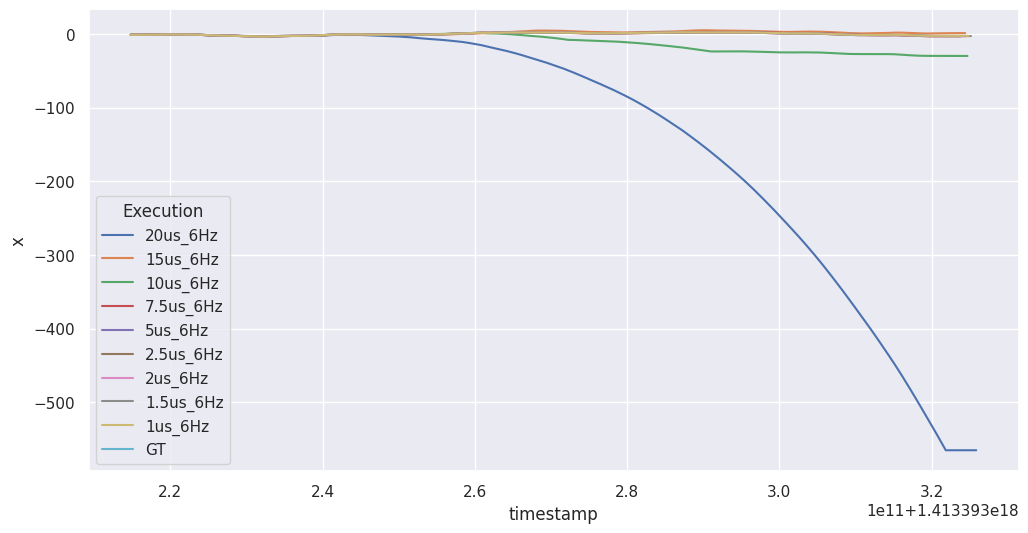

In [154]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution', hue_order = sorted_folders)
# ax.set(ylim=(-4, 4))

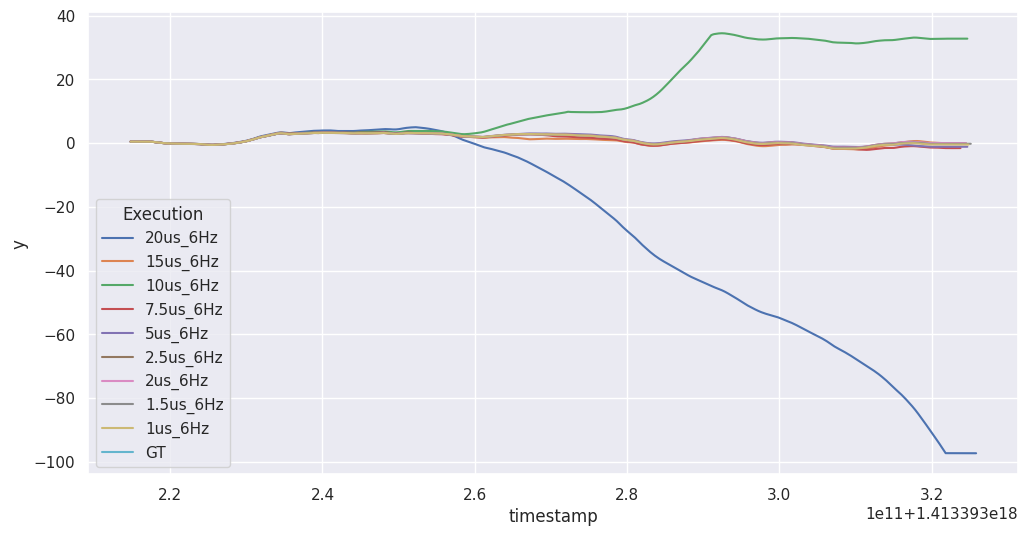

In [155]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution', hue_order = sorted_folders)
# ax.set(ylim=(-4, 4))

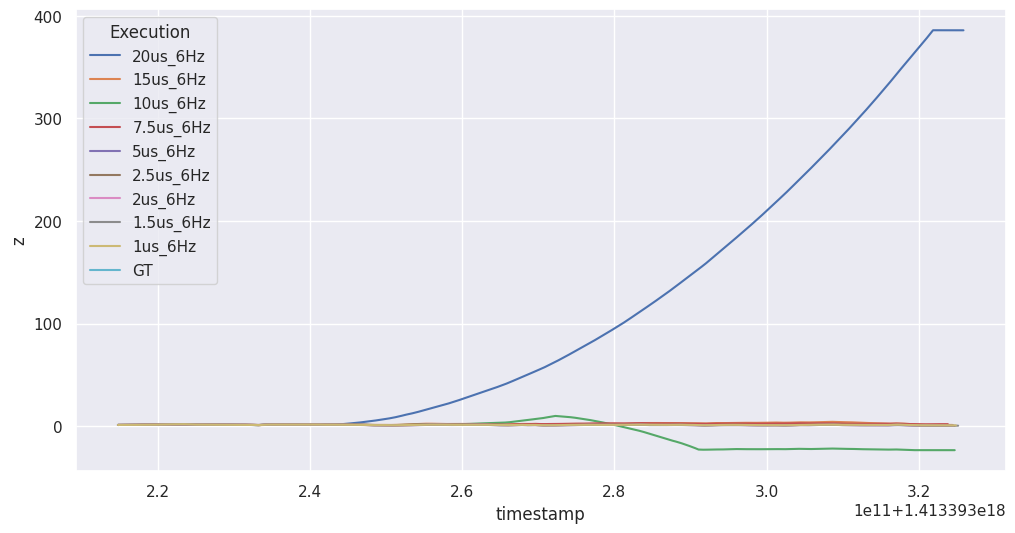

In [156]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution', hue_order = sorted_folders)

In [136]:
np.set_printoptions(precision=20)
pd.set_option('display.float_format', '{:.20f}'.format)

In [137]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for df in dfs:
    error_df = generate_error_gt_vio_pose(gt_df, df, DEBUG=False, SHOW_GRAPHS=False)
    values[df.iloc[0]['Execution']] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

541
541
541
541
541
542
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []
541
541
541
541
540
541
541
541
542
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []
541
541
540


In [138]:
values.keys()

dict_keys(['1.5us_4Hz', '10us_4Hz', '5us_6Hz', '2us_4Hz', '2.5us_6Hz', '20us_4Hz', '1us_6Hz', '2us_6Hz', '1us_4Hz', '15us_4Hz', '7.5us_6Hz', '2.5us_4Hz', '10us_6Hz', '15us_6Hz', '20us_6Hz', '1.5us_6Hz', '5us_4Hz', '7.5us_4Hz'])

In [139]:
error_distance_dfs = []

for i in values.keys():
    err_df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution':i})
    error_distance_dfs.append(err_df)

error_distance_dfs = pd.concat(error_distance_dfs)

In [140]:
error_distance_dfs['Execution'].unique()

array(['1.5us_4Hz', '10us_4Hz', '5us_6Hz', '2us_4Hz', '2.5us_6Hz',
       '20us_4Hz', '1us_6Hz', '2us_6Hz', '1us_4Hz', '15us_4Hz',
       '7.5us_6Hz', '2.5us_4Hz', '10us_6Hz', '15us_6Hz', '20us_6Hz',
       '1.5us_6Hz', '5us_4Hz', '7.5us_4Hz'], dtype=object)

In [141]:
sorted_folders

['5us_6Hz',
 '2.5us_6Hz',
 '1us_6Hz',
 '2us_6Hz',
 '7.5us_6Hz',
 '10us_6Hz',
 '15us_6Hz',
 '20us_6Hz',
 '1.5us_6Hz',
 'GT']

Text(0.5, 1.0, 'Error as Distance Increases')

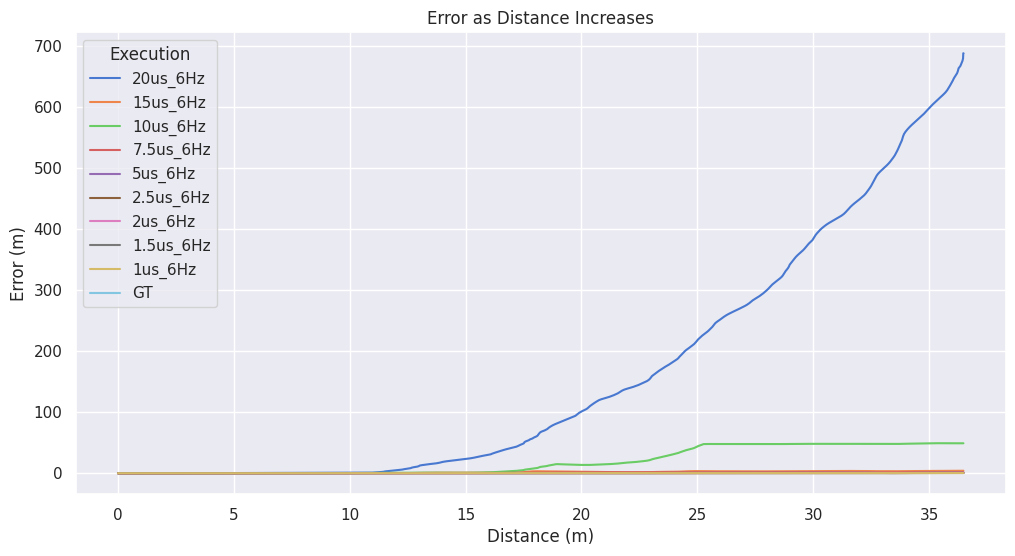

In [157]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases'

g = sns.lineplot(data = error_distance_dfs, 
                 x='Distance (m)', 
                 y = 'Error (m)', 
                 hue='Execution', 
                 legend='full', 
                 palette='muted', 
                 hue_order = sorted_folders[:])
g.set_title(title)

In [178]:
sorted_folders[3:]

['7.5us_6Hz', '5us_6Hz', '2.5us_6Hz', '2us_6Hz', '1.5us_6Hz', '1us_6Hz', 'GT']

In [179]:
filtered_folders = sorted_folders[3:]

In [180]:
error_distance_dfs_filtered = error_distance_dfs[error_distance_dfs['Execution'].isin(filtered_folders)]

In [181]:
error_distance_dfs_filtered

,Distance (m),Error (m),Execution
0,0.00000000000000000000,0.00005741950887992281,5us_6Hz
1,0.00133344913806076747,0.00064054745999078796,5us_6Hz
2,0.00468585063132989643,0.00081697143753637702,5us_6Hz
3,0.00630611185037854155,0.00130648334124449294,5us_6Hz
4,0.00829811942856870273,0.00190459215124721927,5us_6Hz
...,...,...,...
536,36.47888562405816514911,0.42900308191111941047,1.5us_6Hz
537,36.47957351257100810926,0.42754786695498092630,1.5us_6Hz
538,36.48174198336143092547,0.41796941144559757175,1.5us_6Hz
539,36.48259573053832127698,0.41780650856281009720,1.5us_6Hz


Text(0.5, 1.0, 'Error as Distance Increases - TO_BE_CHANGED')

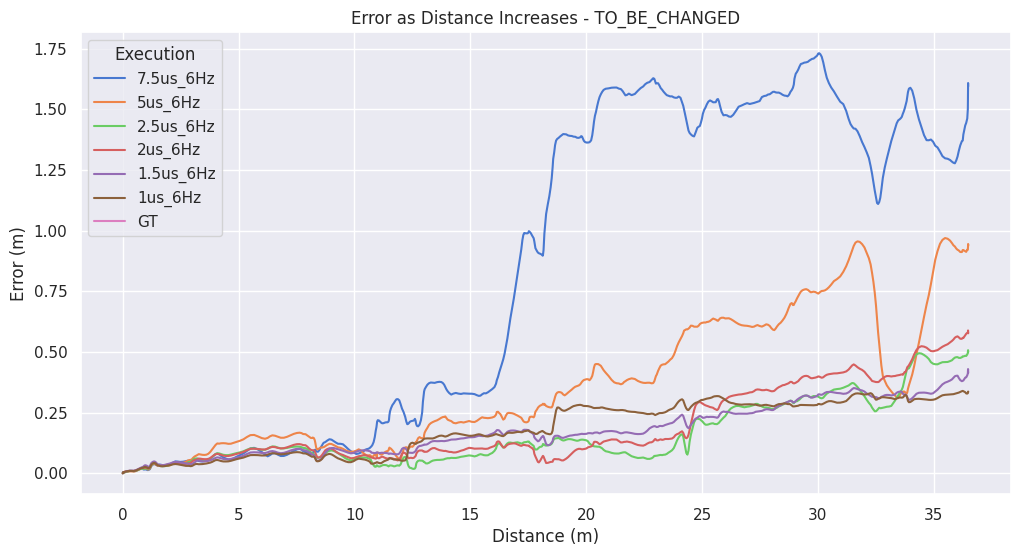

In [182]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - TO_BE_CHANGED'

g = sns.lineplot(data = error_distance_dfs_filtered, x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted', hue_order = filtered_folders)
g.set_title(title)